In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = "/content/drive/MyDrive/data/archive"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if 'metadata.csv' in files:
        print(os.path.join(root, 'metadata.csv'))
        break

/content/drive/MyDrive/data/archive/metadata.csv


In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/data/archive/metadata.csv")
for alg in sorted(df["algorithm"].unique()):
  print(f"\nAlgorithm{alg}")
  print(df[df["algorithm"]==alg]["exp_name"].unique()[:20])



Algorithm0
['cv4_fastspeech2' 'ek1_tacotron2' 'ljspeech_deepvoice3'
 'ljspeech_fast_pitch' 'ljspeech_fastspeech2' 'ljspeech_glow-tts'
 'ljspeech_tacotron2-DCA' 'ljspeech_tacotron2-DDC'
 'ljspeech_tacotron2-DDC_ph' 'ljspeech_vits' 'sam_tacotron-DDC'
 'silero_lj_16khz' 'silero_lj_16khz_enhanced'
 'tf_ljspeech_FASTSPEECH2_MB-MELGAN' 'tf_ljspeech_FASTSPEECH2_MELGAN'
 'tf_ljspeech_FASTSPEECH2_MELGAN-STFT' 'tf_ljspeech_FASTSPEECH_MB-MELGAN'
 'tf_ljspeech_FASTSPEECH_MELGAN' 'tf_ljspeech_FASTSPEECH_MELGAN-STFT'
 'tf_ljspeech_TACOTRON_MELGAN']

Algorithm1
['cv4_fastspeech2' 'ek1_tacotron2' 'ljspeech_deepvoice3'
 'ljspeech_fast_pitch' 'ljspeech_fastspeech2' 'ljspeech_glow-tts'
 'ljspeech_tacotron2-DCA' 'ljspeech_tacotron2-DDC'
 'ljspeech_tacotron2-DDC_ph' 'ljspeech_vits' 'sam_tacotron-DDC'
 'silero_lj_16khz' 'silero_lj_16khz_enhanced'
 'tf_ljspeech_FASTSPEECH2_MB-MELGAN' 'tf_ljspeech_FASTSPEECH2_MELGAN'
 'tf_ljspeech_FASTSPEECH2_MELGAN-STFT' 'tf_ljspeech_FASTSPEECH_MB-MELGAN'
 'tf_ljspeech_FAST

In [ ]:
print("Total samples:",len(df))

Total samples: 34850


In [ ]:
print("unique TTS systems:",df["exp_name"].nunique())

unique TTS systems: 25


In [ ]:
print("unique speakers:",df["speaker_id"].nunique())

unique speakers: 219


In [ ]:
print("\nsamples per TTS system:")
print(df["exp_name"].value_counts())


samples per TTS system:
exp_name
cv4_fastspeech2                        1394
ek1_tacotron2                          1394
ljspeech_deepvoice3                    1394
ljspeech_fast_pitch                    1394
ljspeech_fastspeech2                   1394
ljspeech_glow-tts                      1394
ljspeech_tacotron2-DCA                 1394
ljspeech_tacotron2-DDC                 1394
ljspeech_tacotron2-DDC_ph              1394
ljspeech_vits                          1394
sam_tacotron-DDC                       1394
silero_lj_16khz                        1394
silero_lj_16khz_enhanced               1394
tf_ljspeech_FASTSPEECH2_MB-MELGAN      1394
tf_ljspeech_FASTSPEECH2_MELGAN         1394
tf_ljspeech_FASTSPEECH2_MELGAN-STFT    1394
tf_ljspeech_FASTSPEECH_MB-MELGAN       1394
tf_ljspeech_FASTSPEECH_MELGAN          1394
tf_ljspeech_FASTSPEECH_MELGAN-STFT     1394
tf_ljspeech_TACOTRON_MELGAN            1394
tf_ljspeech_TACOTRON_MELGAN-STFT       1394
vctk_deepvoice3_speakerrandom          139

In [ ]:
print(df.groupby("exp_name")["speaker_id"].nunique())

exp_name
cv4_fastspeech2                          1
ek1_tacotron2                            1
ljspeech_deepvoice3                      1
ljspeech_fast_pitch                      1
ljspeech_fastspeech2                     1
ljspeech_glow-tts                        1
ljspeech_tacotron2-DCA                   1
ljspeech_tacotron2-DDC                   1
ljspeech_tacotron2-DDC_ph                1
ljspeech_vits                            1
sam_tacotron-DDC                         1
silero_lj_16khz                          1
silero_lj_16khz_enhanced                 1
tf_ljspeech_FASTSPEECH2_MB-MELGAN        1
tf_ljspeech_FASTSPEECH2_MELGAN           1
tf_ljspeech_FASTSPEECH2_MELGAN-STFT      1
tf_ljspeech_FASTSPEECH_MB-MELGAN         1
tf_ljspeech_FASTSPEECH_MELGAN            1
tf_ljspeech_FASTSPEECH_MELGAN-STFT       1
tf_ljspeech_TACOTRON_MELGAN              1
tf_ljspeech_TACOTRON_MELGAN-STFT         1
vctk_deepvoice3_speakerrandom          107
vctk_fast_pitch_speakerrandom          108
vc

In [ ]:
systems = ["ljspeech_vits","ljspeech_fastspeech2","ljspeech_glow-tts"]
for system in systems:
  row = df[df["exp_name"]==system].iloc[0]
  print("\nsystem:",system)
  print("speaker:",row["speaker_id"])
  print("Audio Path:",row["audio_path"])


system: ljspeech_vits
speaker: lj
Audio Path: /kaggle/input/kothac1112131415/tmp/Dataset/ljspeech_vits/1059df5984efbd52824922d66db379ff.wav

system: ljspeech_fastspeech2
speaker: lj
Audio Path: /kaggle/input/kothaf01/tmp/Dataset/ljspeech_fastspeech2/7385c5f867ef1df649da476859b8f224.wav

system: ljspeech_glow-tts
speaker: lj
Audio Path: /kaggle/input/kothac678910/tmp/Dataset/ljspeech_glow-tts/b7d53f6c8301665c8c1ae0d647208ecf.wav


sampling rate: 22050
duration: 7.001587301587302
shape: (154385,)


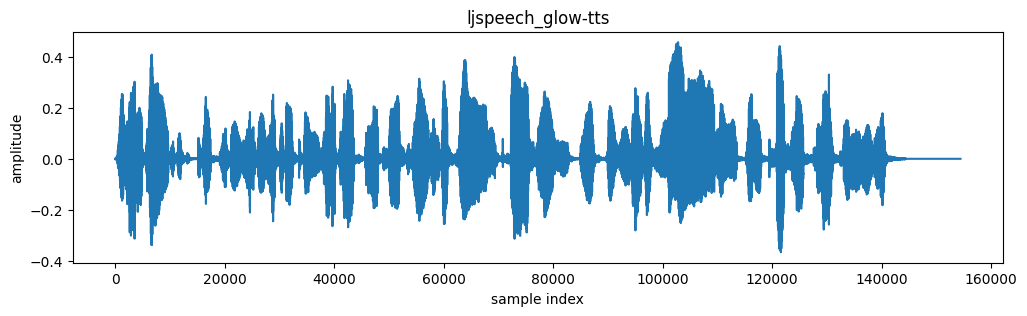

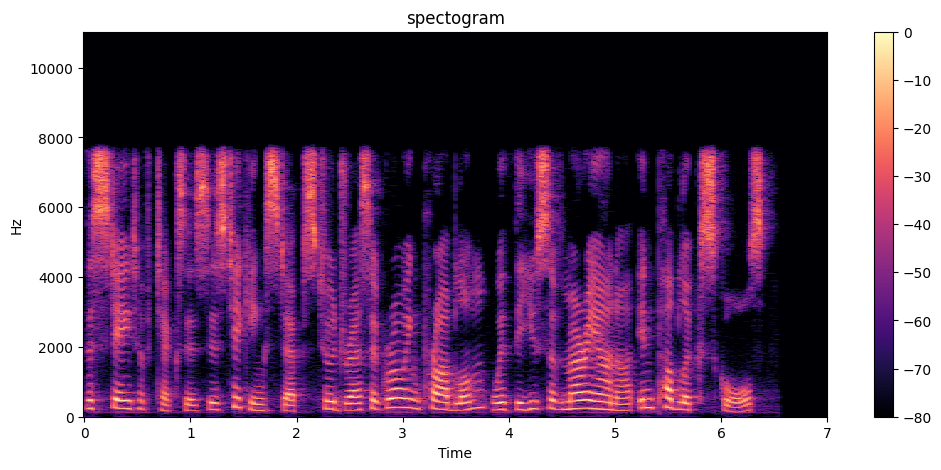

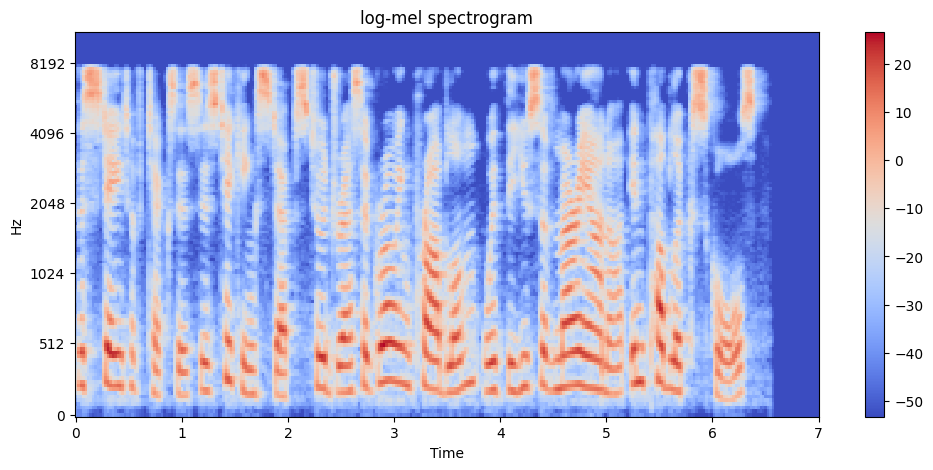

sampling rate: 22050
duration: 3.959092970521542
shape: (87298,)


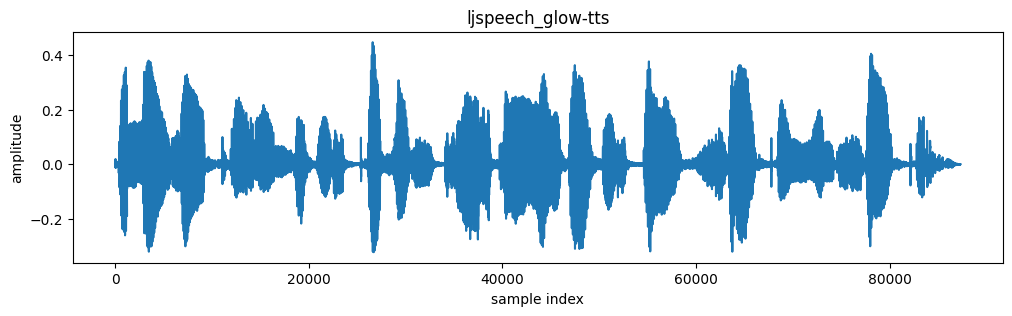

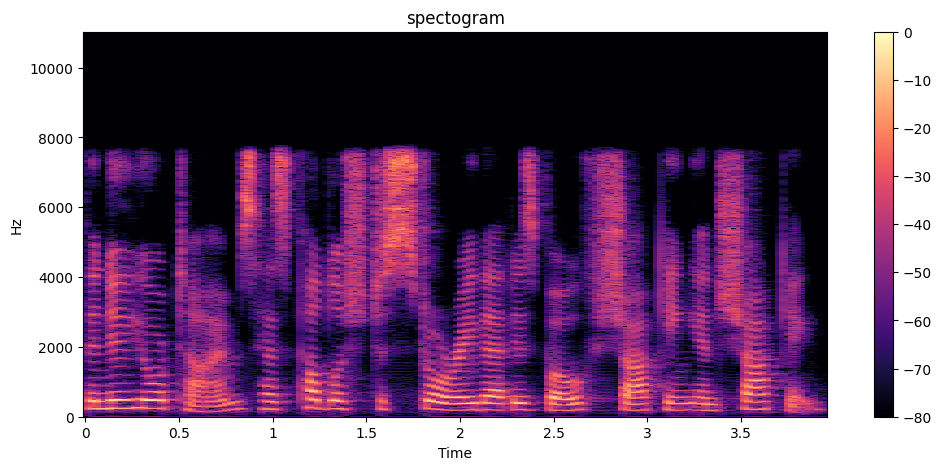

sampling rate: 22050
duration: 6.978412698412699
shape: (153874,)


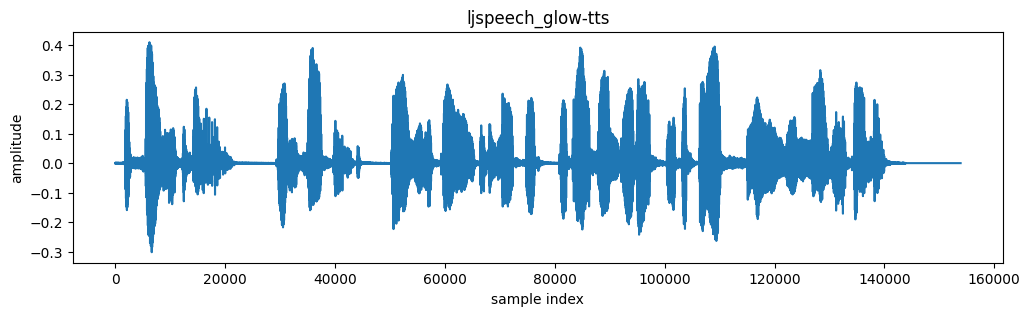

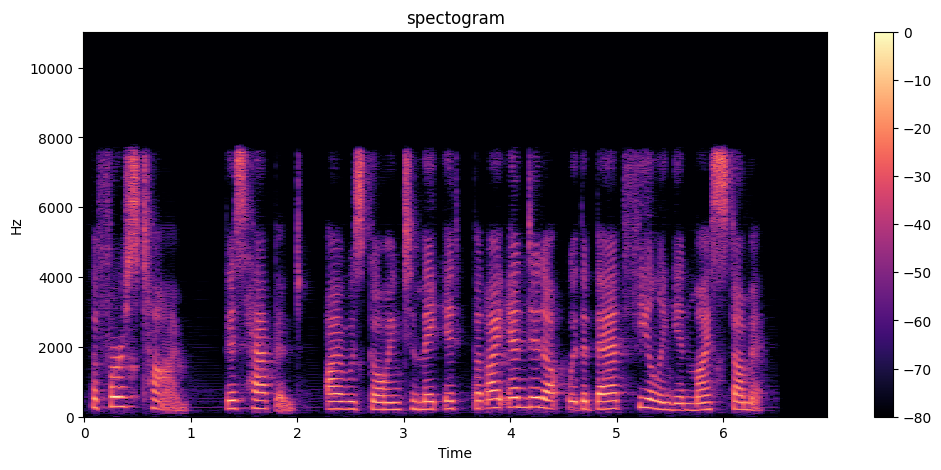

In [ ]:

import matplotlib.pyplot as plt
import librosa.display
import numpy as np

import librosa
y,sr = librosa.load("/content/drive/MyDrive/data/archive/wavs/ljspeech_vits/1059df5984efbd52824922d66db379ff.wav")
print("sampling rate:",sr)
print("duration:",len(y)/sr)
print("shape:",y.shape)
plt.figure(figsize=(12,3))
plt.plot(y)
plt.title(system)
plt.xlabel("sample index")
plt.ylabel("amplitude")
plt.show()
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)),ref = np.max)
plt.figure(figsize=(12,5))
librosa.display.specshow(D,sr=sr,x_axis='time',y_axis='hz')
plt.colorbar()
plt.title("spectogram")
plt.show()

mel = librosa.feature.melspectrogram(y=y,sr=sr,n_mels=128)
log_mel = librosa.power_to_db(mel)
plt.figure(figsize=(12,5))
librosa.display.specshow(log_mel,sr=sr,x_axis='time',y_axis='mel')
plt.colorbar()
plt.title("log-mel spectrogram")
plt.show()


import librosa
y,sr = librosa.load("/content/drive/MyDrive/data/archive/wavs/ljspeech_fastspeech2/7385c5f867ef1df649da476859b8f224.wav")
print('sampling rate:',sr)
print("duration:",len(y)/sr)
print("shape:",y.shape)
plt.figure(figsize=(12,3))
plt.plot(y)
plt.title(system)
plt.xlabel("sample index")
plt.ylabel("amplitude")
plt.show()
D1 = librosa.amplitude_to_db(np.abs(librosa.stft(y)),ref = np.max)
plt.figure(figsize=(12,5))
librosa.display.specshow(D1,sr=sr,x_axis='time',y_axis='hz')
plt.colorbar()
plt.title("spectogram")
plt.show()

import librosa
y,sr = librosa.load("/content/drive/MyDrive/data/archive/wavs/ljspeech_glow-tts/b7d53f6c8301665c8c1ae0d647208ecf.wav")
print("sampling rate:",sr)
print("duration:",len(y)/sr)
print("shape:",y.shape)
plt.figure(figsize=(12,3))
plt.plot(y)
plt.title(system)
plt.xlabel("sample index")
plt.ylabel("amplitude")
plt.show()
D2 = librosa.amplitude_to_db(np.abs(librosa.stft(y)),ref = np.max)
plt.figure(figsize=(12,5))
librosa.display.specshow(D2,sr=sr,x_axis='time',y_axis='hz')
plt.colorbar()
plt.title("spectogram")
plt.show()

(1, 302)
0.1741223872102649
(1, 302)
centroid mean: 2390.5606334528256
(1, 302)
bandwidth mean: 1477.2413362520917
(1, 302)
rolloff mean: 3881.8589772609685
(13, 302)


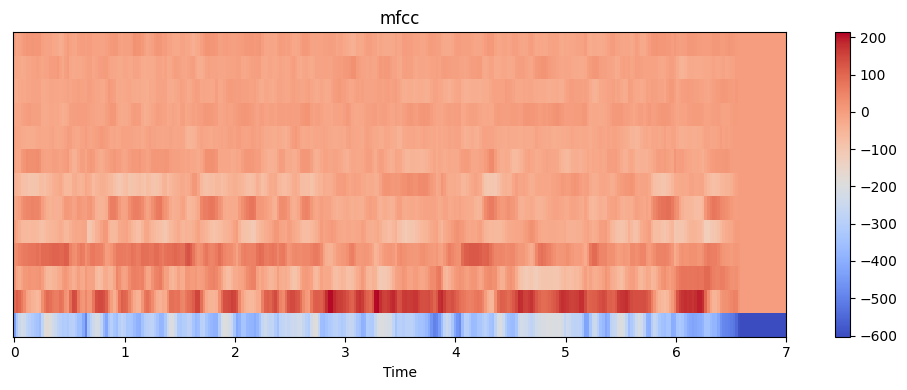

MFCC1:
Mean =  -332.39746
STd =  99.19062

MFCC2:
Mean =  84.194275
STd =  72.13745

MFCC3:
Mean =  -12.687463
STd =  44.901466

MFCC4:
Mean =  41.253536
STd =  36.388683

MFCC5:
Mean =  -39.494503
STd =  31.204079

(1, 302)
Mean RMS: 0.053758197
STd RMS: 0.033889886


In [ ]:
y,sr = librosa.load("/content/drive/MyDrive/data/archive/wavs/ljspeech_vits/1059df5984efbd52824922d66db379ff.wav")
zcr = librosa.feature.zero_crossing_rate(y)
print(zcr.shape)
print(zcr.mean())

centroid = librosa.feature.spectral_centroid(y=y,sr=sr)
print(centroid.shape)
print("centroid mean:",centroid.mean())

bandwidth = librosa.feature.spectral_bandwidth(y=y,sr=sr)
print(bandwidth.shape)
print("bandwidth mean:",bandwidth.mean())

rolloff = librosa.feature.spectral_rolloff(y=y,sr=sr)
print(rolloff.shape)
print("rolloff mean:",rolloff.mean())

mfcc = librosa.feature.mfcc(y=y,sr=sr,n_mfcc=13)
print(mfcc.shape)
plt.figure(figsize=(10,4))
librosa.display.specshow(mfcc,x_axis='time')
plt.colorbar()
plt.title('mfcc')
plt.tight_layout()
plt.show()


mfcc_mean = mfcc.mean(axis=1)
mfcc_std = mfcc.std(axis=1)

for i in range(5):
  print(f"MFCC{i+1}:")
  print("Mean = ",mfcc[i].mean())
  print("STd = ",mfcc[i].std())
  print()


rms =librosa.feature.rms(y=y)
print(rms.shape)
print("Mean RMS:",rms.mean())
print("STd RMS:",rms.std())

In [ ]:
delta = librosa.feature.delta(mfcc)
print(delta.shape)

(13, 302)


In [ ]:
delta2 = librosa.feature.delta(mfcc,order = 2)
print(delta2.shape)

(13, 302)


In [ ]:
import librosa
import random

AUDIO_DIR = "/content/drive/MyDrive/data/archive/wavs"

audio_paths = [
    f"{AUDIO_DIR}/{exp_name}/{track}"
    for exp_name, track in zip(df["exp_name"], df["track"])
]

print(audio_paths[0])

for f in random.sample(audio_paths, 10):
    _, sr = librosa.load(f, sr=None)
    print(sr)

/content/drive/MyDrive/data/archive/wavs/cv4_fastspeech2/f7e4c5be19ec118868a533f949e2fb09.wav
16000
16000
16000
16000
16000
16000
16000
16000
16000
16000


In [ ]:
import numpy as np
import librosa


def extract_features(audio_path):
  y , sr = librosa.load(audio_path,sr = None)
  mfcc = librosa.feature.mfcc(y=y,sr=sr,n_mfcc=13)
  delta = librosa.feature.delta(mfcc)
  delta2 = librosa.feature.delta(mfcc,order=2)
  zcr = librosa.feature.zero_crossing_rate(y)
  centroid = librosa.feature.spectral_centroid(y=y,sr=sr)
  bandwidth = librosa.feature.spectral_bandwidth(y=y,sr=sr)
  rolloff = librosa.feature.spectral_rolloff(y=y,sr=sr)
  rms = librosa.feature.rms(y=y)

  features = np.concatenate([
      mfcc.mean(axis=1),
      mfcc.std(axis=1),
      delta.mean(axis=1),
      delta.std(axis=1),
      delta2.mean(axis=1),
      delta2.std(axis=1),
      [zcr.mean(),zcr.std()],
      [centroid.mean(),centroid.std()],
      [bandwidth.mean(),bandwidth.std()],
      [rolloff.mean(),rolloff.std()],
      [rms.mean(),rms.std()]

  ])

  return features


path = "/content/drive/MyDrive/data/archive/wavs/cv4_fastspeech2/f7e4c5be19ec118868a533f949e2fb09.wav"

x = extract_features(path)

print("Shape:", x.shape)
print("First 10 features:", x[:10])

Shape: (88,)
First 10 features: [-231.092453    114.4970932     7.18829584   36.901474     15.57319546
   -2.37065315  -16.08282852  -22.34956169   -6.49746323   -8.33599186]


In [ ]:
feature_names = []

# MFCC
for i in range(13):
    feature_names.append(f"mfcc_{i+1}_mean")

for i in range(13):
    feature_names.append(f"mfcc_{i+1}_std")

# Delta
for i in range(13):
    feature_names.append(f"delta_{i+1}_mean")

for i in range(13):
    feature_names.append(f"delta_{i+1}_std")

# Delta2
for i in range(13):
    feature_names.append(f"delta2_{i+1}_mean")

for i in range(13):
    feature_names.append(f"delta2_{i+1}_std")

feature_names += [
    "zcr_mean","zcr_std",
    "centroid_mean","centroid_std",
    "bandwidth_mean","bandwidth_std",
    "rolloff_mean","rolloff_std",
    "rms_mean","rms_std"
]

print(feature_names)

['mfcc_1_mean', 'mfcc_2_mean', 'mfcc_3_mean', 'mfcc_4_mean', 'mfcc_5_mean', 'mfcc_6_mean', 'mfcc_7_mean', 'mfcc_8_mean', 'mfcc_9_mean', 'mfcc_10_mean', 'mfcc_11_mean', 'mfcc_12_mean', 'mfcc_13_mean', 'mfcc_1_std', 'mfcc_2_std', 'mfcc_3_std', 'mfcc_4_std', 'mfcc_5_std', 'mfcc_6_std', 'mfcc_7_std', 'mfcc_8_std', 'mfcc_9_std', 'mfcc_10_std', 'mfcc_11_std', 'mfcc_12_std', 'mfcc_13_std', 'delta_1_mean', 'delta_2_mean', 'delta_3_mean', 'delta_4_mean', 'delta_5_mean', 'delta_6_mean', 'delta_7_mean', 'delta_8_mean', 'delta_9_mean', 'delta_10_mean', 'delta_11_mean', 'delta_12_mean', 'delta_13_mean', 'delta_1_std', 'delta_2_std', 'delta_3_std', 'delta_4_std', 'delta_5_std', 'delta_6_std', 'delta_7_std', 'delta_8_std', 'delta_9_std', 'delta_10_std', 'delta_11_std', 'delta_12_std', 'delta_13_std', 'delta2_1_mean', 'delta2_2_mean', 'delta2_3_mean', 'delta2_4_mean', 'delta2_5_mean', 'delta2_6_mean', 'delta2_7_mean', 'delta2_8_mean', 'delta2_9_mean', 'delta2_10_mean', 'delta2_11_mean', 'delta2_12_mea

In [ ]:
import os
import pandas as pd
from tqdm import tqdm

AUDIO_DIR = "/content/drive/MyDrive/data/archive/wavs"

# Initialize X and y. If this cell is run from the top, these lists will be reset.
X = []
y = []

# To resume from a specific point, set start_index to the last successfully processed index.
# Based on the previous output, it stopped after processing 11863 items.
start_index = 0 # Change to 0 if you want to restart from the beginning.

# Iterate over the DataFrame, starting from 'start_index'
# The 'total' and 'initial' parameters for tqdm are adjusted for accurate progress bar display when resuming.
for index, row in tqdm(df.iloc[start_index:].iterrows(), total=len(df) - start_index, initial=start_index):
  audio_path = os.path.join(
      AUDIO_DIR, row["exp_name"], row["track"]

  )

  try :
    features = extract_features(audio_path)
    X.append(features)
    y.append(row["exp_name"])
  except Exception as e:
      print(f"Skipping {audio_path}")
      print(e)

100%|██████████| 34850/34850 [2:24:37<00:00,  4.02it/s]


In [ ]:
import pandas as pd
import numpy as np

X = np.array(X)

df_features = pd.DataFrame(
    X,
    columns=feature_names
)

df_features["label"] = y

print(df_features.shape)
df_features.head()

(34850, 89)


,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean,mfcc_4_mean,mfcc_5_mean,mfcc_6_mean,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,...,zcr_std,centroid_mean,centroid_std,bandwidth_mean,bandwidth_std,rolloff_mean,rolloff_std,rms_mean,rms_std,label
0,-231.092453,114.497093,7.188296,36.901474,15.573195,-2.370653,-16.082829,-22.349562,-6.497463,-8.335992,...,0.078171,1284.025650,815.399337,1456.643474,439.382416,2537.016369,1602.698185,0.098040,0.065750,cv4_fastspeech2
1,-378.915619,179.476929,7.342104,22.781954,-10.691727,-15.086653,-10.566176,-16.604702,-12.440489,-6.909233,...,0.046608,768.599104,527.990748,853.704625,384.714270,1224.487305,1093.701382,0.038649,0.017452,cv4_fastspeech2
2,-398.897552,123.861023,24.483349,56.993763,30.592896,-6.037459,-16.340183,7.622237,-5.345806,-2.834416,...,0.057057,1015.578830,734.880553,1331.795505,413.485124,1999.853516,1482.542164,0.017969,0.007009,cv4_fastspeech2
3,-389.487488,112.788864,9.360864,38.784508,11.073611,3.233735,-8.266920,-0.416876,-7.667834,-0.461566,...,0.093561,1436.330974,984.904540,1485.180291,478.154285,2748.250000,1722.625422,0.011842,0.004678,cv4_fastspeech2
4,-270.491730,125.467178,-7.004885,14.316159,16.208467,-23.108959,-11.284864,-13.697815,-19.507792,2.349782,...,0.107127,1330.360801,914.569696,1365.553718,585.261582,2496.250000,1744.846793,0.072086,0.036683,cv4_fastspeech2


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/data/archive"

# Fast, compact
df_features.to_parquet(
    os.path.join(SAVE_DIR, "tts_features.parquet"),
    index=False
)

# Human-readable backup
df_features.to_csv(
    os.path.join(SAVE_DIR, "tts_features.csv"),
    index=False
)

print("Feature extraction completed!")

Feature extraction completed!
